In [1]:
from pathlib import Path
import pickle
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
# Load data
animals=["rat", "human"]
root=Path("/Users/danielaegas/")/"OneDrive - Open Brain Institute"/"Human_Connectivity_Paper"/"conn_matrix"

# Save the dictionary to a pickle file
sc={}
for animal in animals:
    path_in=f"{root}/simplex_counts/{animal}_full_sc.pkl"
    with open(path_in, 'rb') as f:
        sc[animal] = pickle.load(f)

    # Fix typo
    sc[animal]["bishuffled"] = sc[animal].pop("bishuffuled")

colors={"human":"teal",
        "rat":"blueviolet"}

### Suggested plot, others below

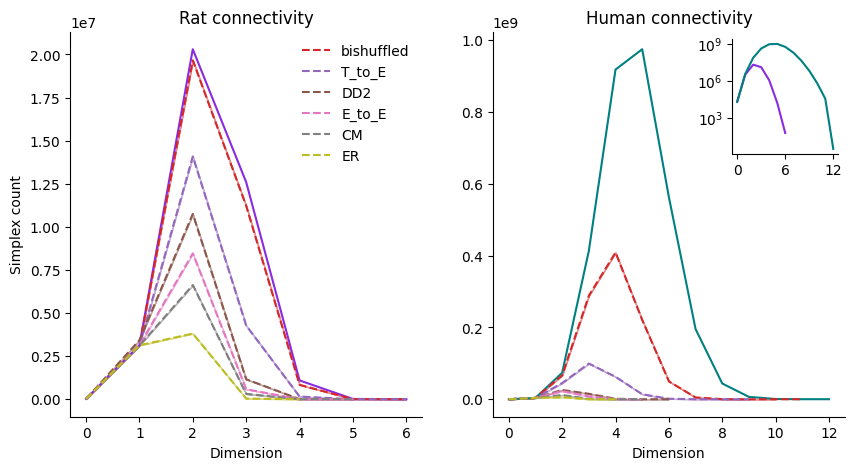

In [3]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig, axs = plt.subplots(1, 2, figsize=(10, 5),sharey=False)
for i, animal in enumerate(animals):
    axs[i].plot(sc[animal]["functional"], color=colors[animal])

    for j,control in enumerate(['bishuffled', 'T_to_E',  'DD2', 'E_to_E', 'CM', 'ER'], start=3): #controls ordered by decreasing complexity
        if control=="functional": continue
        mean=sc[animal][control].mean()
        sem=sc[animal][control].sem()
        axs[i].plot(mean, linestyle='--', color=f"C{j}", label=control)
        axs[i].fill_between(range(len(mean)), mean-sem, mean+sem, color=f"C{j}",alpha=0.5)

    axs[i].set_title(f"{animal.capitalize()} connectivity")
    axs[i].set_xlabel("Dimension")
    axs[i].spines[["top","right"]].set_visible(False)
    #axs[i].set_yscale("log")
axs[0].set_ylabel("Simplex count")
axs[0].legend(frameon=False)

# Create an inset axis inside axs[0]
inset_ax = inset_axes(axs[1], width="30%", height="30%", loc="upper right")
for animal in animals: 
    inset_ax.plot(sc[animal]["functional"], color=colors[animal])
inset_ax.set_xticks([0,6,12])
inset_ax.set_yscale("log")
inset_ax.spines[["top", "right"]].set_visible(False)



### Not log scale 

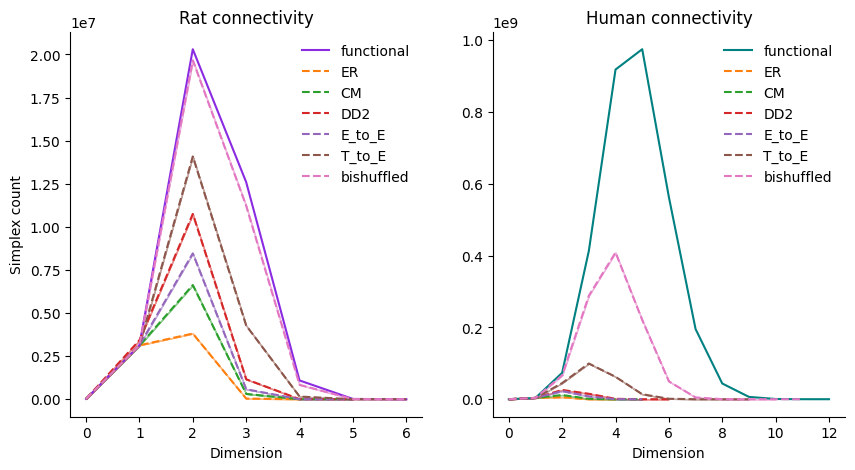

In [4]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5),sharey=False)
for i, animal in enumerate(animals):
    axs[i].plot(sc[animal]["functional"], label="functional", color=colors[animal])

    for j,control in enumerate(sc[animal].keys()):
        if control=="functional": continue
        mean=sc[animal][control].mean()
        sem=sc[animal][control].sem()
        axs[i].plot(mean, linestyle='--', color=f"C{j}", label=control)
        axs[i].fill_between(range(len(mean)), mean-sem, mean+sem, color=f"C{j}",alpha=0.5)

    axs[i].legend(frameon=False)
    axs[i].set_title(f"{animal.capitalize()} connectivity")
    axs[i].set_xlabel("Dimension")
    axs[0].set_ylabel("Simplex count")
    axs[i].spines[["top","right"]].set_visible(False)


### Shared y-axis, log-scale

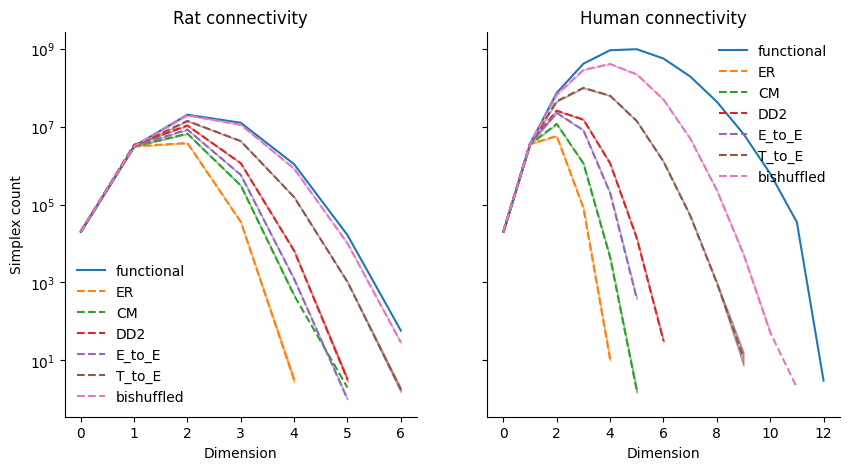

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5),sharey=True)
for i, animal in enumerate(animals):
    # Load the data
    axs[i].plot(sc[animal]["functional"], label="functional")

    for j,control in enumerate(sc[animal].keys()):
        if control=="functional": continue
        mean=sc[animal][control].mean()
        sem=sc[animal][control].sem()
        axs[i].plot(mean, linestyle='--', color=f"C{j}", label=control)
        axs[i].fill_between(range(len(mean)), mean-sem, mean+sem, color=f"C{j}",alpha=0.5)

    axs[i].legend(frameon=False)
    axs[i].set_title(f"{animal.capitalize()} connectivity")
    axs[i].set_xlabel("Dimension")
    axs[0].set_ylabel("Simplex count")
    axs[i].spines[["top","right"]].set_visible(False)
    axs[i].set_yscale("log")




#### Differences

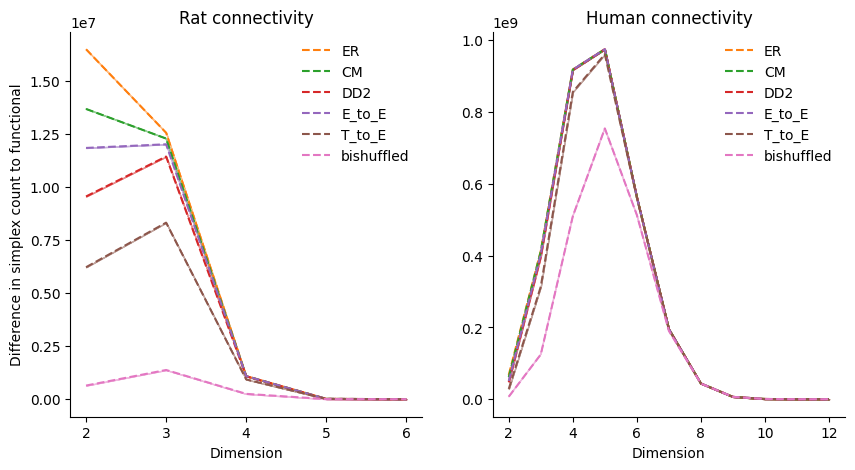

In [6]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
for i, animal in enumerate(animals):
    # Load the data

    for j,control in enumerate(sc[animal].keys()):
        if control=="functional": continue
        df=-sc[animal][control].reindex(columns=sc[animal]["functional"].index, fill_value=0).sub(sc[animal]["functional"], axis=1).drop(columns=[0,1])
        mean=df.mean()
        sem=df.sem()
        axs[i].plot(mean.index, mean, linestyle='--', color=f"C{j}", label=control)
        axs[i].fill_between(mean.index, mean-sem, mean+sem, color=f"C{j}",alpha=0.5)

    axs[i].legend(frameon=False)
    axs[i].set_title(f"{animal.capitalize()} connectivity")
    axs[i].set_xlabel("Dimension")
    axs[0].set_ylabel("Difference in simplex count to functional")
    axs[i].spines[["top","right"]].set_visible(False)
    #axs[i].set_yscale("log")

